<a href="https://colab.research.google.com/github/KU-BIG/KUBIG_2026_SPRING/blob/main/KUBIG%20CONTEST/ML%20Team%201/%EB%AA%A8%EB%8D%B8%EB%A7%81_%EC%9B%90%EC%B6%A9%EC%84%B1_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
df=pd.read_csv('/content/drive/MyDrive/df_final.csv')

df=df.drop(columns='Unnamed: 0')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,year,week,rain_nat,erer,rain_diff,water_temp,DO,BOD,COD,pH,...,cases_bacteria,cases_virus,cases_protozoa,temp,humidity,pop_area,sum_weighted_area,sum_flood_area,avg_flood_intensity,pop_weighted_intensity
0,2015,1.0,3.772672,0.0,3.772672,1.701246,15.622046,1.936856,3.764894,6.748502,...,6,89,2,-0.262836,3.199137,0.0,0.0,0.0,0.0,0.0
1,2015,2.0,1.185419,0.0,-2.587254,3.712223,13.466400,2.436846,4.732934,7.682216,...,12,78,1,-0.013854,3.658332,0.0,0.0,0.0,0.0,0.0
2,2015,3.0,2.691617,0.0,1.506199,3.724155,14.035902,2.379334,4.717393,7.709611,...,13,117,5,0.037085,3.580605,0.0,0.0,0.0,0.0,0.0
3,2015,4.0,2.586522,0.0,-0.105095,3.998386,13.746543,1.649368,4.705090,7.859229,...,22,205,3,0.100451,4.251323,0.0,0.0,0.0,0.0,0.0
4,2015,5.0,0.509471,0.0,-2.077051,5.263631,13.063065,3.622871,5.704383,7.775275,...,18,201,2,0.006128,4.068619,0.0,0.0,0.0,0.0,0.0


In [ ]:
# 월 변수 생성

df['year']=df['year'].astype(int)
df['week']=df['week'].astype(int)

def first_saturday_of_year(y: int)->pd.Timestamp:
    jan1=pd.Timestamp(f'{y}-01-01')
    days_ahead=(5-jan1.weekday())%7
    return jan1+pd.Timedelta(days=days_ahead)

first_sat=df['year'].map(first_saturday_of_year)
df['week_start']=first_sat+pd.to_timedelta(7*(df['week']-1), unit='D')

df['month']=df['week_start'].dt.month

df.head()

,year,week,rain_nat,erer,rain_diff,water_temp,DO,BOD,COD,pH,...,cases_protozoa,temp,humidity,pop_area,sum_weighted_area,sum_flood_area,avg_flood_intensity,pop_weighted_intensity,week_start,month
0,2015,1,3.772672,0.0,3.772672,1.701246,15.622046,1.936856,3.764894,6.748502,...,2,-0.262836,3.199137,0.0,0.0,0.0,0.0,0.0,2015-01-03,1
1,2015,2,1.185419,0.0,-2.587254,3.712223,13.466400,2.436846,4.732934,7.682216,...,1,-0.013854,3.658332,0.0,0.0,0.0,0.0,0.0,2015-01-10,1
2,2015,3,2.691617,0.0,1.506199,3.724155,14.035902,2.379334,4.717393,7.709611,...,5,0.037085,3.580605,0.0,0.0,0.0,0.0,0.0,2015-01-17,1
3,2015,4,2.586522,0.0,-0.105095,3.998386,13.746543,1.649368,4.705090,7.859229,...,3,0.100451,4.251323,0.0,0.0,0.0,0.0,0.0,2015-01-24,1
4,2015,5,0.509471,0.0,-2.077051,5.263631,13.063065,3.622871,5.704383,7.775275,...,2,0.006128,4.068619,0.0,0.0,0.0,0.0,0.0,2015-01-31,1


# 1 지연상관 확인

In [ ]:
df2=df.drop(columns=['year', 'month', 'week', 'week_start', 'cases_virus', 'cases_bacteria'])
df2=df2.rename(columns={'cases_protozoa':'cases'})

In [ ]:
def lag_correlation_all(df, targets, max_lag=8):
    results=[]
    feature_cols=df.columns.drop(targets)

    for target in targets:

        for col in feature_cols:
            for k in range(0, max_lag+1):
                corr=df[target].corr(df[col].shift(k))
                results.append({
                    'target':target,
                    'feature':col,
                    'lag':k,
                    'correlation':corr
                })
    return pd.DataFrame(results)

In [ ]:
targets=['cases']

lag_corr_df=lag_correlation_all(df2, targets)

In [ ]:
top2=(
    lag_corr_df.assign(abs_corr=lambda x: x['correlation'].abs()).groupby(
        ['target', 'feature']).apply(lambda x: x.nlargest(3, 'abs_corr'))
)

top2

/tmp/ipython-input-3689244599.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ['target', 'feature']).apply(lambda x: x.nlargest(3, 'abs_corr'))


target                 feature  lag  \
target feature                                                          
cases  BOD                    49   cases                     BOD    4   
                              51   cases                     BOD    6   
                              46   cases                     BOD    1   
       COD                    58   cases                     COD    4   
                              55   cases                     COD    1   
                              60   cases                     COD    6   
       DO                     42   cases                      DO    6   
                              43   cases                      DO    7   
                              40   cases                      DO    4   
       avg_flood_intensity    141  cases     avg_flood_intensity    6   
                              142  cases     avg_flood_intensity    7   
                              143  cases     avg_flood_intensity    8   
       coli_log_mean          74   cases           coli_log_mean    2   
                              79   cases           coli_log_mean    7   
                              75   cases           coli_log_mean    3   
       coli_mean              83   cases               coli_mean    2   
                              86   cases               coli_mean    5   
                              81   cases               coli_mean    0   
       erer                   10   cases                    erer    1   
                              12   cases                    erer    3   
                              13   cases                    erer    4   
       humidity               104  cases                humidity    5   
                              102  cases                humidity    3   
                              100  cases                humidity    1   
       pH                     65   cases                      pH    2   
                              71   cases                      pH    8   
                              64   cases                      pH    1   
       pop_area               113  cases                pop_area    5   
                              116  cases                pop_area    8   
                              112  cases                pop_area    4   
       pop_weighted_intensity 150  cases  pop_weighted_intensity    6   
                              146  cases  pop_weighted_intensity    2   
                              152  cases  pop_weighted_intensity    8   
       rain_diff              19   cases               rain_diff    1   
                              18   cases               rain_diff    0   
                              25   cases               rain_diff    7   
       rain_nat               4    cases                rain_nat    4   
                              3    cases                rain_nat    3   
                              1    cases                rain_nat    1   
       sum_flood_area         131  cases          sum_flood_area    5   
                              134  cases          sum_flood_area    8   
                              130  cases          sum_flood_area    4   
       sum_weighted_area      122  cases       sum_weighted_area    5   
                              121  cases       sum_weighted_area    4   
                              125  cases       sum_weighted_area    8   
       temp                   96   cases                    temp    6   
                              95   cases                    temp    5   
                              97   cases                    temp    7   
       water_temp             33   cases              water_temp    6   
                              34   cases              water_temp    7   
                              35   cases              water_temp    8   

                                   correlation  abs_corr  
target feature                                            
cases  BOD                    49      0.071710

# 2 자기 상관

In [ ]:
df2=df.drop(columns=['week', 'week_start', 'cases_virus', 'cases_bacteria'])
df2=df2.rename(columns={'cases_protozoa':'cases'})
df2.columns

Index(['year', 'rain_nat', 'erer', 'rain_diff', 'water_temp', 'DO', 'BOD',
       'COD', 'pH', 'coli_log_mean', 'coli_mean', 'cases', 'temp', 'humidity',
       'pop_area', 'sum_weighted_area', 'sum_flood_area',
       'avg_flood_intensity', 'pop_weighted_intensity', 'month'],
      dtype='object')

<Figure size 640x480 with 0 Axes>

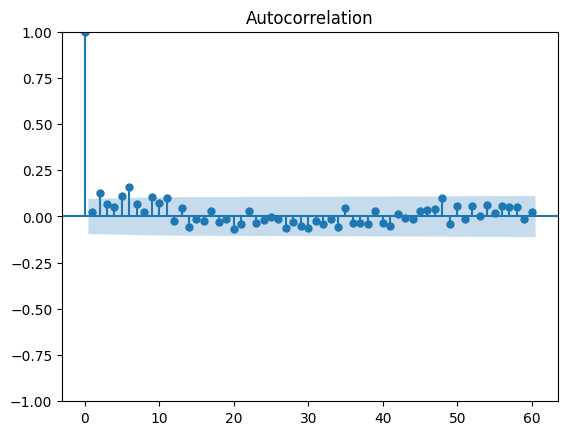

<Figure size 640x480 with 0 Axes>

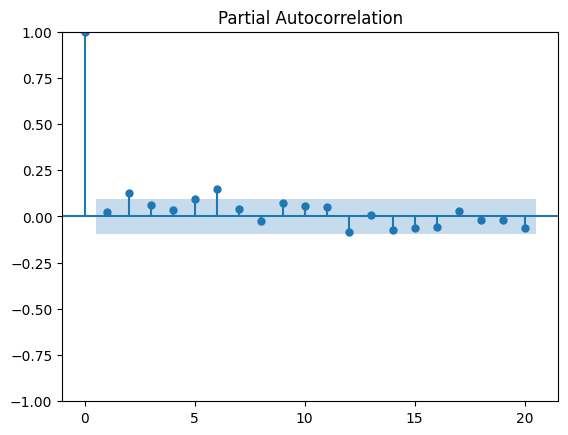

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure()
plot_acf(df2['cases'], lags=60)
plt.show()

plt.figure()
plot_pacf(df2['cases'], lags=20)
plt.show()

# 2 모델링

## 2.1 최종 전처리

In [ ]:
df=df.sort_values(['year', 'week'])

df2=df.drop(columns=['week', 'week_start', 'cases_virus', 'cases_bacteria'])
df2=df2.rename(columns={'cases_protozoa':'cases'})
df2.columns

Index(['year', 'rain_nat', 'erer', 'rain_diff', 'water_temp', 'DO', 'BOD',
       'COD', 'pH', 'coli_log_mean', 'coli_mean', 'cases', 'temp', 'humidity',
       'pop_area', 'sum_weighted_area', 'sum_flood_area',
       'avg_flood_intensity', 'pop_weighted_intensity', 'month'],
      dtype='object')

<Axes: >

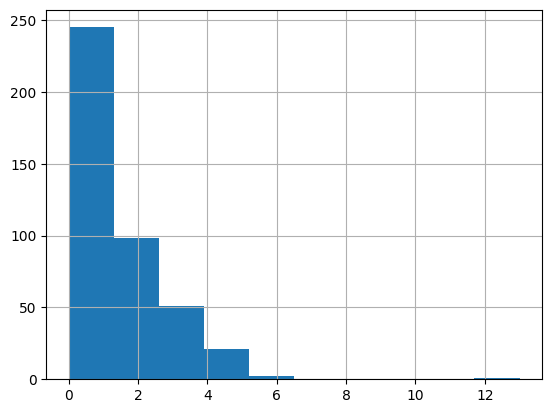

In [ ]:
# 타겟 변수 분포 확인 -> 한쪽으로 치우친 분포이기에 Log 변환 필요
df2.cases.hist()

<Axes: >

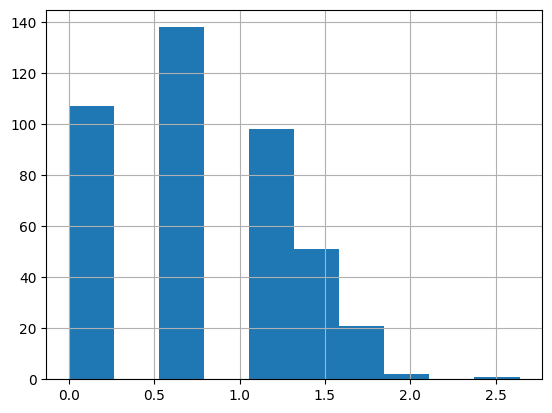

In [ ]:
df2['cases']=np.log1p(df2['cases'])

df2.cases.hist()

In [ ]:
# 지연 변수 생성 함수
def make_lag(df, cols, lags):
    df=df.copy()

    for c in cols:
        for l in lags:
            df[f'{c}_lag{l}']=df[c].shift(l)
    return df

In [ ]:
# 지연 변수 생성
cols=['rain_nat', 'erer', 'rain_diff']
#cols=['erer', 'rain_diff']
df3=make_lag(df2, cols, [3, 4, 5])

cols=['pop_area', 'sum_weighted_area', 'sum_flood_area','avg_flood_intensity', 'pop_weighted_intensity']
#cols=['avg_flood_intensity', 'sum_weighted_area']
df3=make_lag(df3, cols, [5, 6, 7])

cols=['temp', 'humidity']
#cols=['temp']
df3=make_lag(df3, cols, [5, 6, 7])

In [ ]:
df3.columns

Index(['year', 'rain_nat', 'erer', 'rain_diff', 'water_temp', 'DO', 'BOD',
       'COD', 'pH', 'coli_log_mean', 'coli_mean', 'cases', 'temp', 'humidity',
       'pop_area', 'sum_weighted_area', 'sum_flood_area',
       'avg_flood_intensity', 'pop_weighted_intensity', 'month',
       'rain_nat_lag3', 'rain_nat_lag4', 'rain_nat_lag5', 'erer_lag3',
       'erer_lag4', 'erer_lag5', 'rain_diff_lag3', 'rain_diff_lag4',
       'rain_diff_lag5', 'pop_area_lag5', 'pop_area_lag6', 'pop_area_lag7',
       'sum_weighted_area_lag5', 'sum_weighted_area_lag6',
       'sum_weighted_area_lag7', 'sum_flood_area_lag5', 'sum_flood_area_lag6',
       'sum_flood_area_lag7', 'avg_flood_intensity_lag5',
       'avg_flood_intensity_lag6', 'avg_flood_intensity_lag7',
       'pop_weighted_intensity_lag5', 'pop_weighted_intensity_lag6',
       'pop_weighted_intensity_lag7', 'temp_lag5', 'temp_lag6', 'temp_lag7',
       'humidity_lag5', 'humidity_lag6', 'humidity_lag7'],
      dtype='object')

In [ ]:
# 중복 변수 삭제
df4=df3.drop(columns=['rain_nat', 'erer', 'rain_diff', 'pop_area', 'sum_weighted_area', 'sum_flood_area',
       'avg_flood_intensity', 'pop_weighted_intensity', 'temp', 'humidity', 'month', 'water_temp', 'DO', 'BOD', 'COD', 'pH','coli_log_mean', 'coli_mean'])

# 'water_temp', 'DO', 'BOD', 'COD', 'pH','coli_log_mean', 'coli_mean'

In [ ]:
df4.columns

Index(['year', 'cases', 'rain_nat_lag3', 'rain_nat_lag4', 'rain_nat_lag5',
       'erer_lag3', 'erer_lag4', 'erer_lag5', 'rain_diff_lag3',
       'rain_diff_lag4', 'rain_diff_lag5', 'pop_area_lag5', 'pop_area_lag6',
       'pop_area_lag7', 'sum_weighted_area_lag5', 'sum_weighted_area_lag6',
       'sum_weighted_area_lag7', 'sum_flood_area_lag5', 'sum_flood_area_lag6',
       'sum_flood_area_lag7', 'avg_flood_intensity_lag5',
       'avg_flood_intensity_lag6', 'avg_flood_intensity_lag7',
       'pop_weighted_intensity_lag5', 'pop_weighted_intensity_lag6',
       'pop_weighted_intensity_lag7', 'temp_lag5', 'temp_lag6', 'temp_lag7',
       'humidity_lag5', 'humidity_lag6', 'humidity_lag7'],
      dtype='object')

In [ ]:
# test/train set 분리 : 2022년 test set으로, 나머지 train set으로 분리

df_test=df4.loc[df4['year']==2022, :]
df_train=df4.loc[df4['year'].isin(range(2015, 2022)), :]

df_test=df_test.drop(columns='year')
df_train=df_train.drop(columns='year')

X_train=df_train.drop(columns='cases')
y_train=df_train['cases']

X_test=df_test.drop(columns='cases')
y_test=df_test['cases']

## 2.1 LightGBM

In [ ]:
# TimeSeriesSplit 활용하여 하이퍼파라미터 튜닝

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import make_scorer, mean_squared_error
import lightgbm as lgb

# -------------------------
# 1) scoring: RMSE (작을수록 좋게)
# -------------------------
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)

# -------------------------
# 2) TimeSeriesSplit
# -------------------------
tscv = TimeSeriesSplit(n_splits=5)

# -------------------------
# 3) Pipeline + 탐색공간
# -------------------------
pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", lgb.LGBMRegressor(random_state=42, verbosity=-1))
])

param_dist = {
    "model__n_estimators": [300, 500, 800, 1200],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [-1, 3, 4, 5, 6],
    "model__num_leaves": [15, 31, 63, 127],
    "model__min_child_samples": [5, 10, 20, 30, 50],
    "model__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__reg_alpha": [0, 0.1, 0.5, 1.0],
    "model__reg_lambda": [0, 0.1, 0.5, 1.0],
}

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=40,
    scoring=rmse_scorer,
    cv=tscv,
    n_jobs=-1,
    random_state=42,
    verbose=0,
    refit=True,                # CV로 best 찾은 다음, train 전체로 다시 학습
    return_train_score=True
)

# -------------------------
# 4) 튜닝 + CV 성능 확인
# -------------------------
search.fit(X_train, y_train)

cv_best_rmse = -search.best_score_
print("CV best RMSE:", cv_best_rmse)
print("Best params:", search.best_params_)

CV best RMSE: 0.5403268325895487
Best params: {'model__subsample': 1.0, 'model__reg_lambda': 1.0, 'model__reg_alpha': 1.0, 'model__num_leaves': 127, 'model__n_estimators': 300, 'model__min_child_samples': 50, 'model__max_depth': 3, 'model__learning_rate': 0.03, 'model__colsample_bytree': 1.0}


In [ ]:
# 여러 지표를 동시에 계산하도록 수정
search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=40,
    scoring={'RMSE': rmse_scorer, 'R2': 'r2'}, # R2 추가
    cv=tscv,
    n_jobs=-1,
    random_state=42,
    refit='RMSE', # refit 기준을 RMSE로 지정 (중요)
    return_train_score=True
)

search.fit(X_train, y_train)

# 결과 확인
best_index = search.best_index_
cv_best_r2 = search.cv_results_['mean_test_R2'][best_index]
print(f"CV best RMSE: {-search.best_score_:.4f}")
print(f"CV R2 at best RMSE: {cv_best_r2:.4f}")

CV best RMSE: 0.5403
CV R2 at best RMSE: -0.1080


In [ ]:
from sklearn.metrics import r2_score

# 1. 테스트 데이터 예측
y_pred = search.predict(X_test)

# 2. R2 계산
r2 = r2_score(y_test, y_pred)

print(f"Test Set R2 Score: {r2:.4f}")

Test Set R2 Score: 0.0001


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
best_model=search.best_estimator_

y_pred=best_model.predict(X_test)

test_rmse=np.sqrt(mean_squared_error(y_test, y_pred))
bias = (y_test - y_pred).mean()
normalized_rmse=test_rmse/y_test.mean()
print("TEST RMSE:", test_rmse)
print("TEST Bias (mean resid):", bias)
print('Normalized RMSE:', normalized_rmse)

TEST RMSE: 0.4776817804055388
TEST Bias (mean resid): 0.023762956822904913
Normalized RMSE: 0.6343134287704687


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
final_lgb=best_model.named_steps['model']

imp = pd.Series(final_lgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nTop 20 feature importance:")
print(imp.head(30))


Top 20 feature importance:
rain_nat_lag4                  146
humidity_lag5                  124
rain_diff_lag5                 113
humidity_lag6                   94
temp_lag5                       87
erer_lag4                       80
rain_nat_lag3                   73
rain_nat_lag5                   69
rain_diff_lag3                  68
temp_lag6                       49
temp_lag7                       43
humidity_lag7                   42
rain_diff_lag4                  23
erer_lag5                       10
erer_lag3                        4
sum_weighted_area_lag6           0
pop_area_lag7                    0
pop_area_lag6                    0
pop_area_lag5                    0
sum_weighted_area_lag5           0
sum_weighted_area_lag7           0
sum_flood_area_lag5              0
pop_weighted_intensity_lag5      0
avg_flood_intensity_lag7         0
avg_flood_intensity_lag6         0
avg_flood_intensity_lag5         0
sum_flood_area_lag7              0
sum_flood_area_lag6        

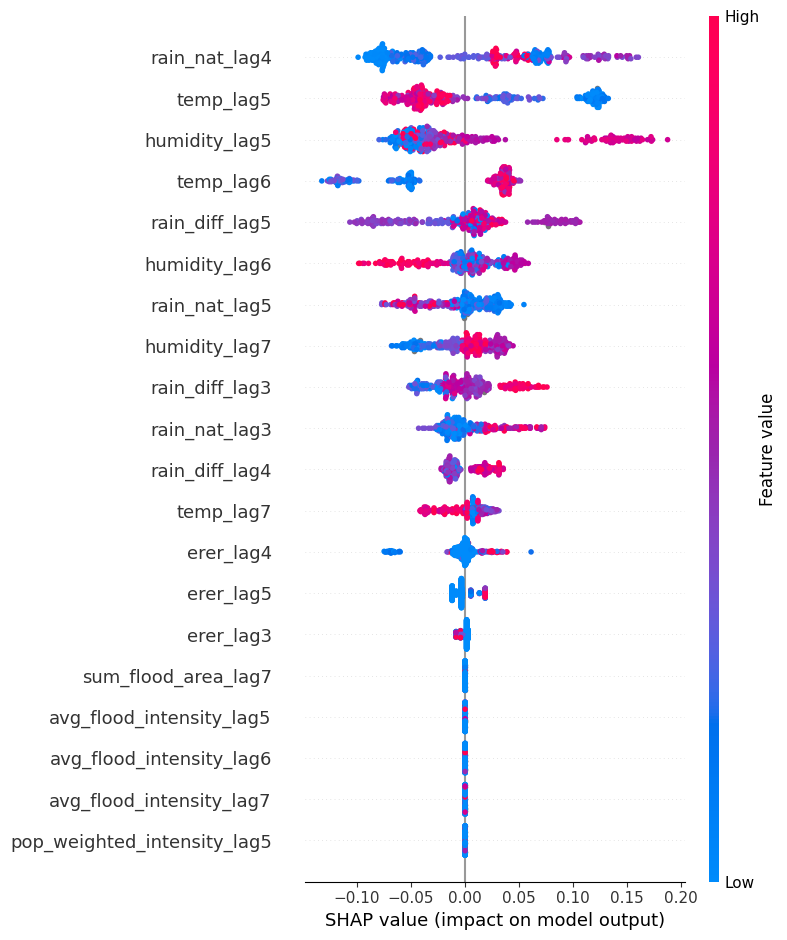

In [ ]:
import shap

explainer = shap.TreeExplainer(final_lgb)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train)

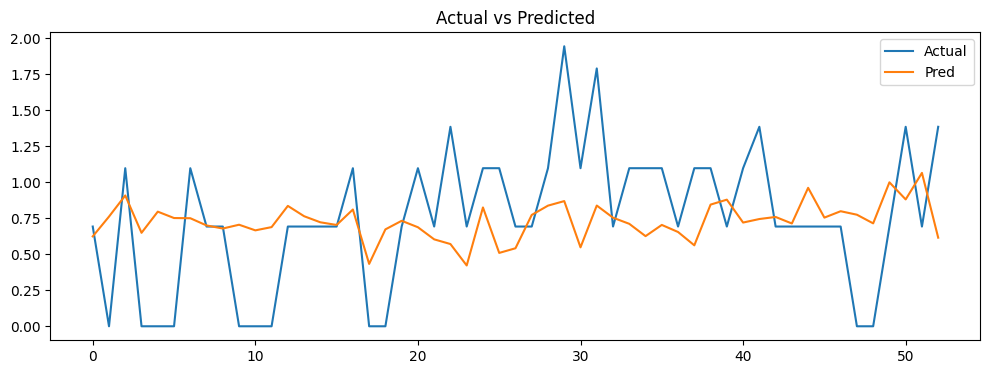

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Pred")
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
# 극단값 예측력

threshold = np.percentile(y_train, 90)

high_risk_true = y_test > threshold
high_risk_pred = y_pred > threshold

recall = (high_risk_true & high_risk_pred).sum() / high_risk_true.sum()
print("High-risk recall:", recall)

High-risk recall: 0.0


## 2.2 XGBoost

In [ ]:
# TimeSeriesSplit 활용하여 하이퍼파라미터 튜닝

import numpy as np
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import make_scorer, mean_squared_error
import xgboost as xgb

# -------------------------
# 1) scoring: RMSE (작을수록 좋게)
# -------------------------
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)

# -------------------------
# 2) TimeSeriesSplit
# -------------------------
tscv = TimeSeriesSplit(n_splits=5)

# -------------------------
# 3) Pipeline + 탐색공간
# -------------------------
pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", xgb.XGBRegressor(random_state=42, objective="reg:squarederror", verbosity=0))
])

param_dist = {
    "model__n_estimators": [300, 500, 800, 1200],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],

    # 트리 복잡도
    "model__max_depth": [2, 3, 4, 5, 6],
    "model__min_child_weight": [1, 3, 5, 7],   # LGB의 min_child_samples와 유사 개념

    # 샘플링
    "model__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],

    # 정규화
    "model__reg_alpha": [0, 0.1, 0.5, 1.0],
    "model__reg_lambda": [0.5, 1.0, 2.0, 5.0],

    # 추가로 넣으면 좋은 것
    "model__gamma": [0, 0.1, 0.3, 0.5],   # 분할 최소 손실 감소량
}

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=40,
    scoring=rmse_scorer,
    cv=tscv,
    n_jobs=-1,
    random_state=42,
    verbose=0,
    refit=True,                # CV로 best 찾은 다음, train 전체로 다시 학습
    return_train_score=True
)

# -------------------------
# 4) 튜닝 + CV 성능 확인
# -------------------------
search.fit(X_train, y_train)

cv_best_rmse = -search.best_score_
print("CV best RMSE:", cv_best_rmse)
print("Best params:", search.best_params_)


CV best RMSE: 0.5463850591509191
Best params: {'model__subsample': 1.0, 'model__reg_lambda': 5.0, 'model__reg_alpha': 0.5, 'model__n_estimators': 500, 'model__min_child_weight': 3, 'model__max_depth': 6, 'model__learning_rate': 0.01, 'model__gamma': 0.5, 'model__colsample_bytree': 0.7}


In [ ]:
best_model=search.best_estimator_

y_pred=best_model.predict(X_test)

test_rmse=np.sqrt(mean_squared_error(y_test, y_pred))
bias = (y_test - y_pred).mean()
normalized_rmse=test_rmse/y_test.mean()
print("TEST RMSE:", test_rmse)
print("TEST Bias (mean resid):", bias)
print('Normalized RMSE:', normalized_rmse)

TEST RMSE: 0.464892689503075
TEST Bias (mean resid): 0.01034590872423029
Normalized RMSE: 0.6173308005146623


In [ ]:
final_xgb=best_model.named_steps['model']

imp = pd.Series(final_xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nTop 20 feature importance:")
print(imp.head(30))


Top 20 feature importance:
humidity_lag5                  0.046071
avg_flood_intensity_lag7       0.045388
pop_area_lag7                  0.044389
sum_flood_area_lag6            0.043158
humidity_lag6                  0.042799
pop_area_lag6                  0.042643
sum_flood_area_lag7            0.042015
rain_diff_lag5                 0.039868
rain_diff_lag3                 0.038255
rain_nat_lag4                  0.038244
erer_lag4                      0.036781
pop_weighted_intensity_lag7    0.035624
avg_flood_intensity_lag5       0.034371
sum_weighted_area_lag6         0.034248
temp_lag7                      0.034064
temp_lag6                      0.034009
rain_nat_lag3                  0.033491
erer_lag5                      0.033431
humidity_lag7                  0.032945
sum_weighted_area_lag7         0.032831
pop_weighted_intensity_lag6    0.032558
temp_lag5                      0.032419
rain_nat_lag5                  0.032142
erer_lag3                      0.031350
rain_diff_la

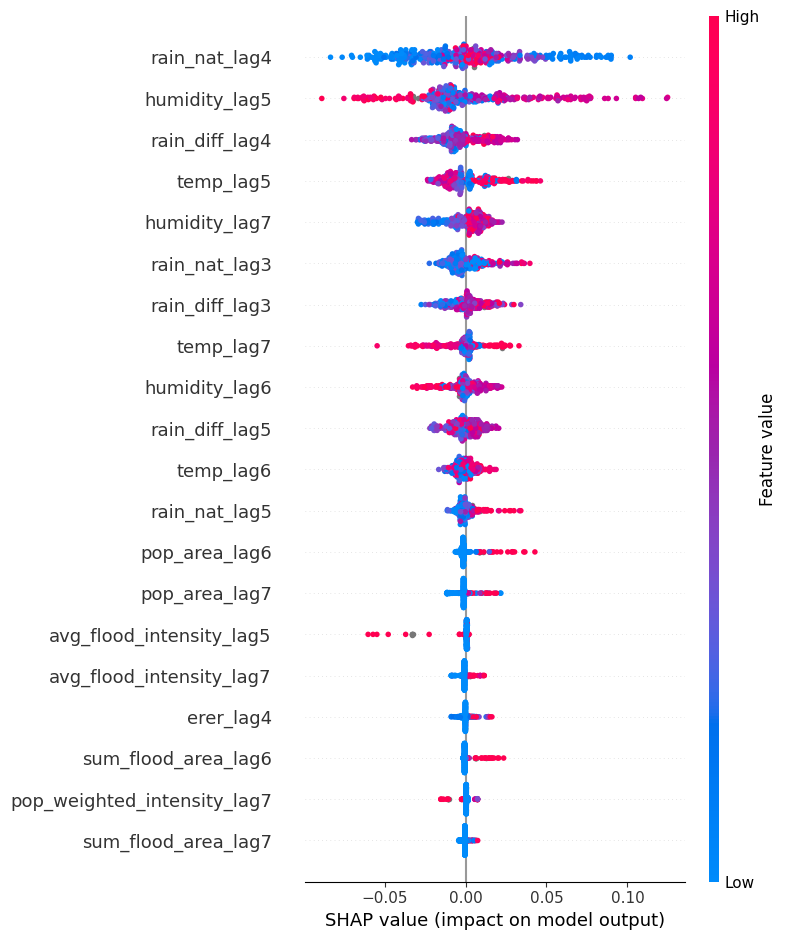

In [ ]:
explainer = shap.TreeExplainer(final_xgb)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train)

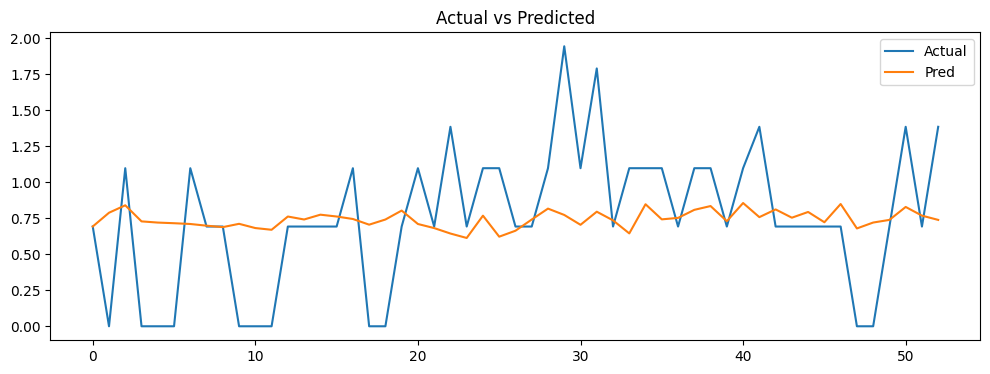

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Pred")
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
threshold = np.percentile(y_train, 90)

high_risk_true = y_test > threshold
high_risk_pred = y_pred > threshold

recall = (high_risk_true & high_risk_pred).sum() / high_risk_true.sum()
print("High-risk recall:", recall)

High-risk recall: 0.0


## 2.3 RandomForest

In [ ]:
# TimeSeriesSplit 활용하여 하이퍼파라미터 튜닝

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

# -------------------------
# 1) scoring: RMSE (작을수록 좋게)
# -------------------------
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)

# -------------------------
# 2) TimeSeriesSplit
# -------------------------
tscv = TimeSeriesSplit(n_splits=5)

# -------------------------
# 3) Pipeline + 탐색공간
# -------------------------
pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_dist = {
    "model__n_estimators": [200, 500, 800, 1200],
    "model__max_depth": [None, 3, 5, 8, 12, 20],

    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8, 12],

    "model__max_features": ["sqrt", "log2", 0.3, 0.5, 0.7, 1.0],

    "model__bootstrap": [True, False]
}

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=40,
    scoring=rmse_scorer,
    cv=tscv,
    n_jobs=-1,
    random_state=42,
    verbose=0,
    refit=True,                # CV로 best 찾은 다음, train 전체로 다시 학습
    return_train_score=True
)

# -------------------------
# 4) 튜닝 + CV 성능 확인
# -------------------------
search.fit(X_train, y_train)

cv_best_rmse = -search.best_score_
print("CV best RMSE:", cv_best_rmse)
print("Best params:", search.best_params_)

CV best RMSE: 0.5394116445844112
Best params: {'model__n_estimators': 800, 'model__min_samples_split': 20, 'model__min_samples_leaf': 12, 'model__max_features': 'log2', 'model__max_depth': 20, 'model__bootstrap': True}


In [ ]:
best_model=search.best_estimator_

y_pred=best_model.predict(X_test)

test_rmse=np.sqrt(mean_squared_error(y_test, y_pred))
bias = (y_test - y_pred).mean()
normalized_rmse=test_rmse/y_test.mean()
print("TEST RMSE:", test_rmse)
print("TEST Bias (mean resid):", bias)
print('Normalized RMSE:', normalized_rmse)

TEST RMSE: 0.4702593308513449
TEST Bias (mean resid): 0.016285529484323234
Normalized RMSE: 0.6244571612306026


In [ ]:
final_rf=best_model.named_steps['model']

imp = pd.Series(final_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nTop 20 feature importance:")
print(imp.head(30))


Top 20 feature importance:
humidity_lag5                  0.100297
rain_diff_lag5                 0.078430
humidity_lag7                  0.077613
rain_nat_lag4                  0.075928
rain_nat_lag3                  0.069601
temp_lag6                      0.069321
rain_diff_lag4                 0.067381
humidity_lag6                  0.066741
temp_lag5                      0.066333
temp_lag7                      0.065632
rain_nat_lag5                  0.061080
rain_diff_lag3                 0.057018
erer_lag4                      0.021949
erer_lag5                      0.018225
erer_lag3                      0.017396
sum_weighted_area_lag6         0.011135
pop_area_lag6                  0.008134
sum_flood_area_lag6            0.008073
pop_weighted_intensity_lag6    0.007336
sum_flood_area_lag5            0.007056
pop_area_lag5                  0.006050
avg_flood_intensity_lag7       0.005778
avg_flood_intensity_lag6       0.005735
pop_weighted_intensity_lag7    0.005499
sum_weighted

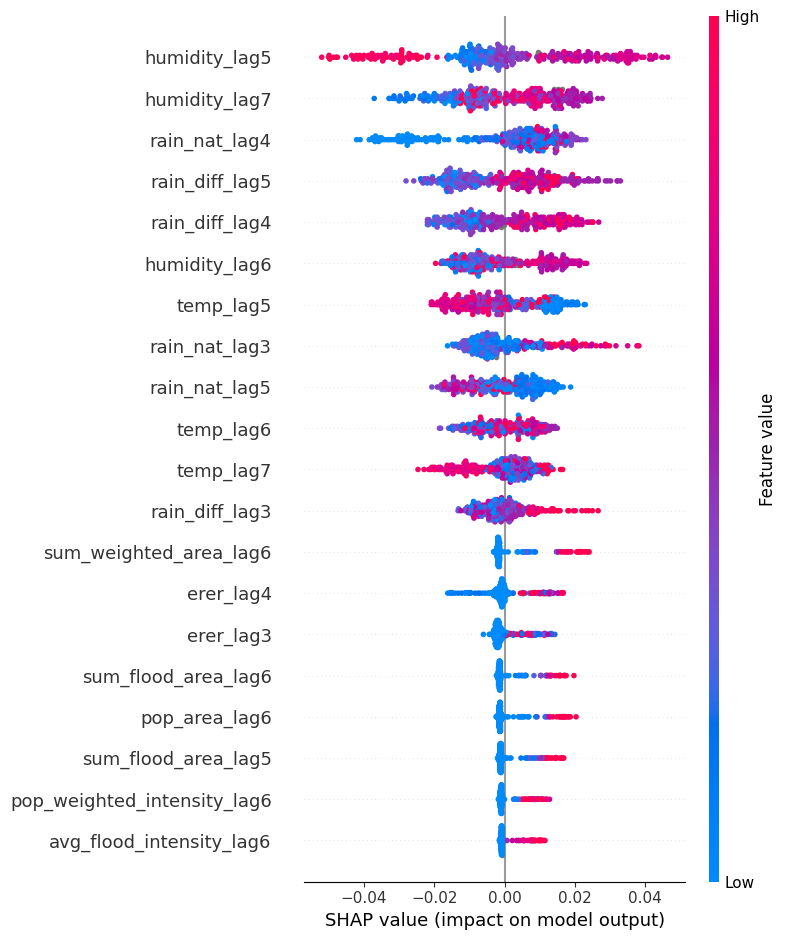

In [ ]:
explainer = shap.TreeExplainer(final_rf)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train)

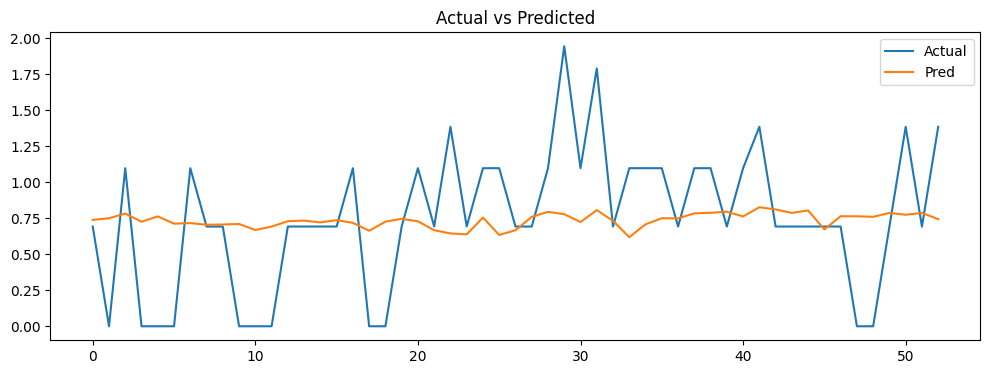

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Pred")
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
# 극한 발생수 예측

threshold = np.percentile(y_train, 90)

high_risk_true = y_test > threshold
high_risk_pred = y_pred > threshold

recall = (high_risk_true & high_risk_pred).sum() / high_risk_true.sum()
print("High-risk recall:", recall)

High-risk recall: 0.0


## 1.2 변수 선택

### 1.2.1 상관계수 확인

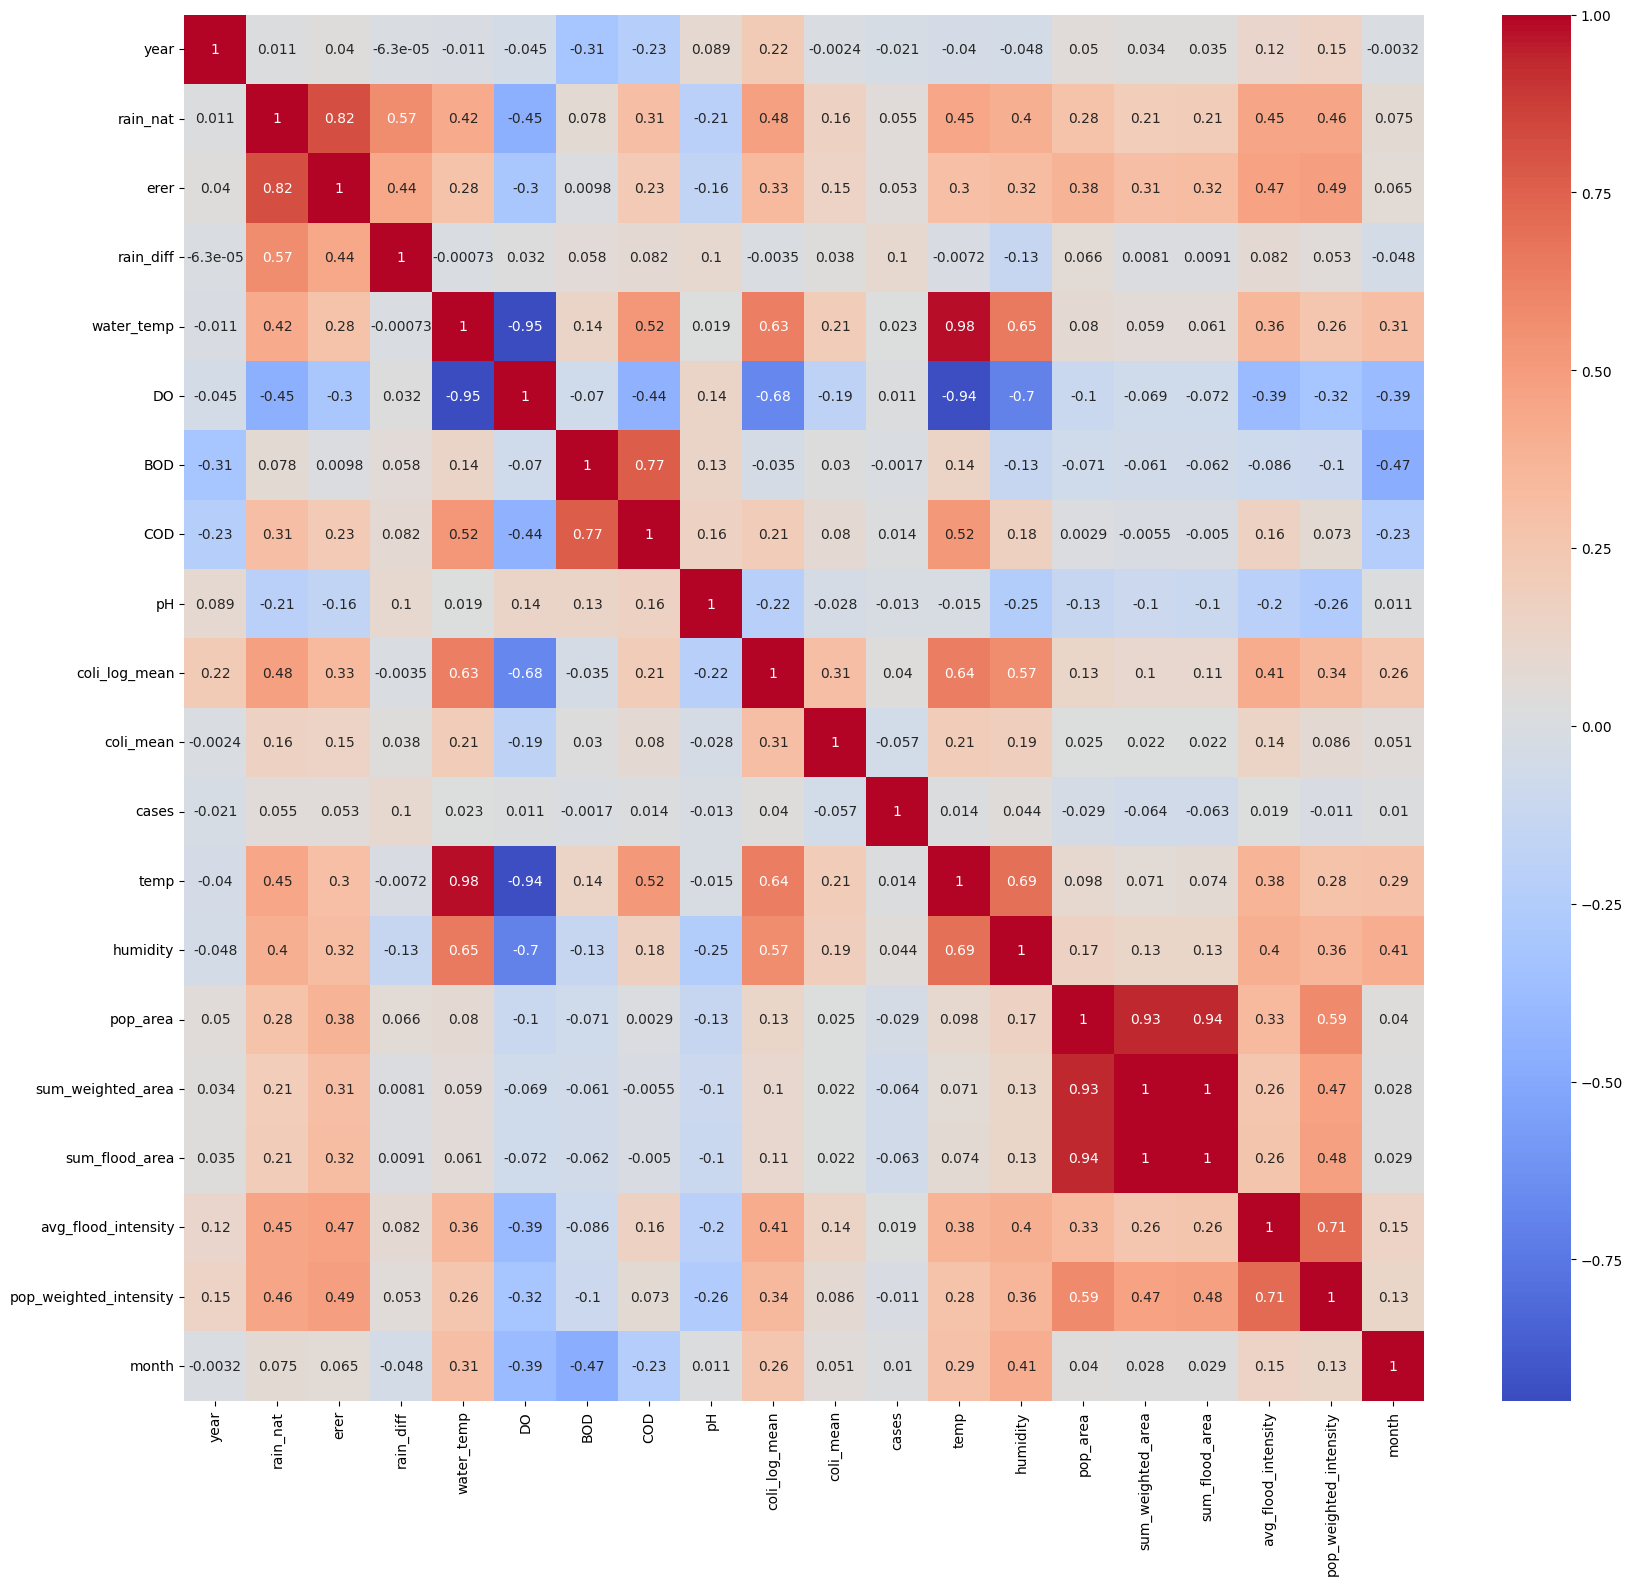

In [ ]:
corr=df2.corr()
plt.figure(figsize=(20, 18))
sns.heatmap(corr, cmap='coolwarm', annot=True)
plt.show()

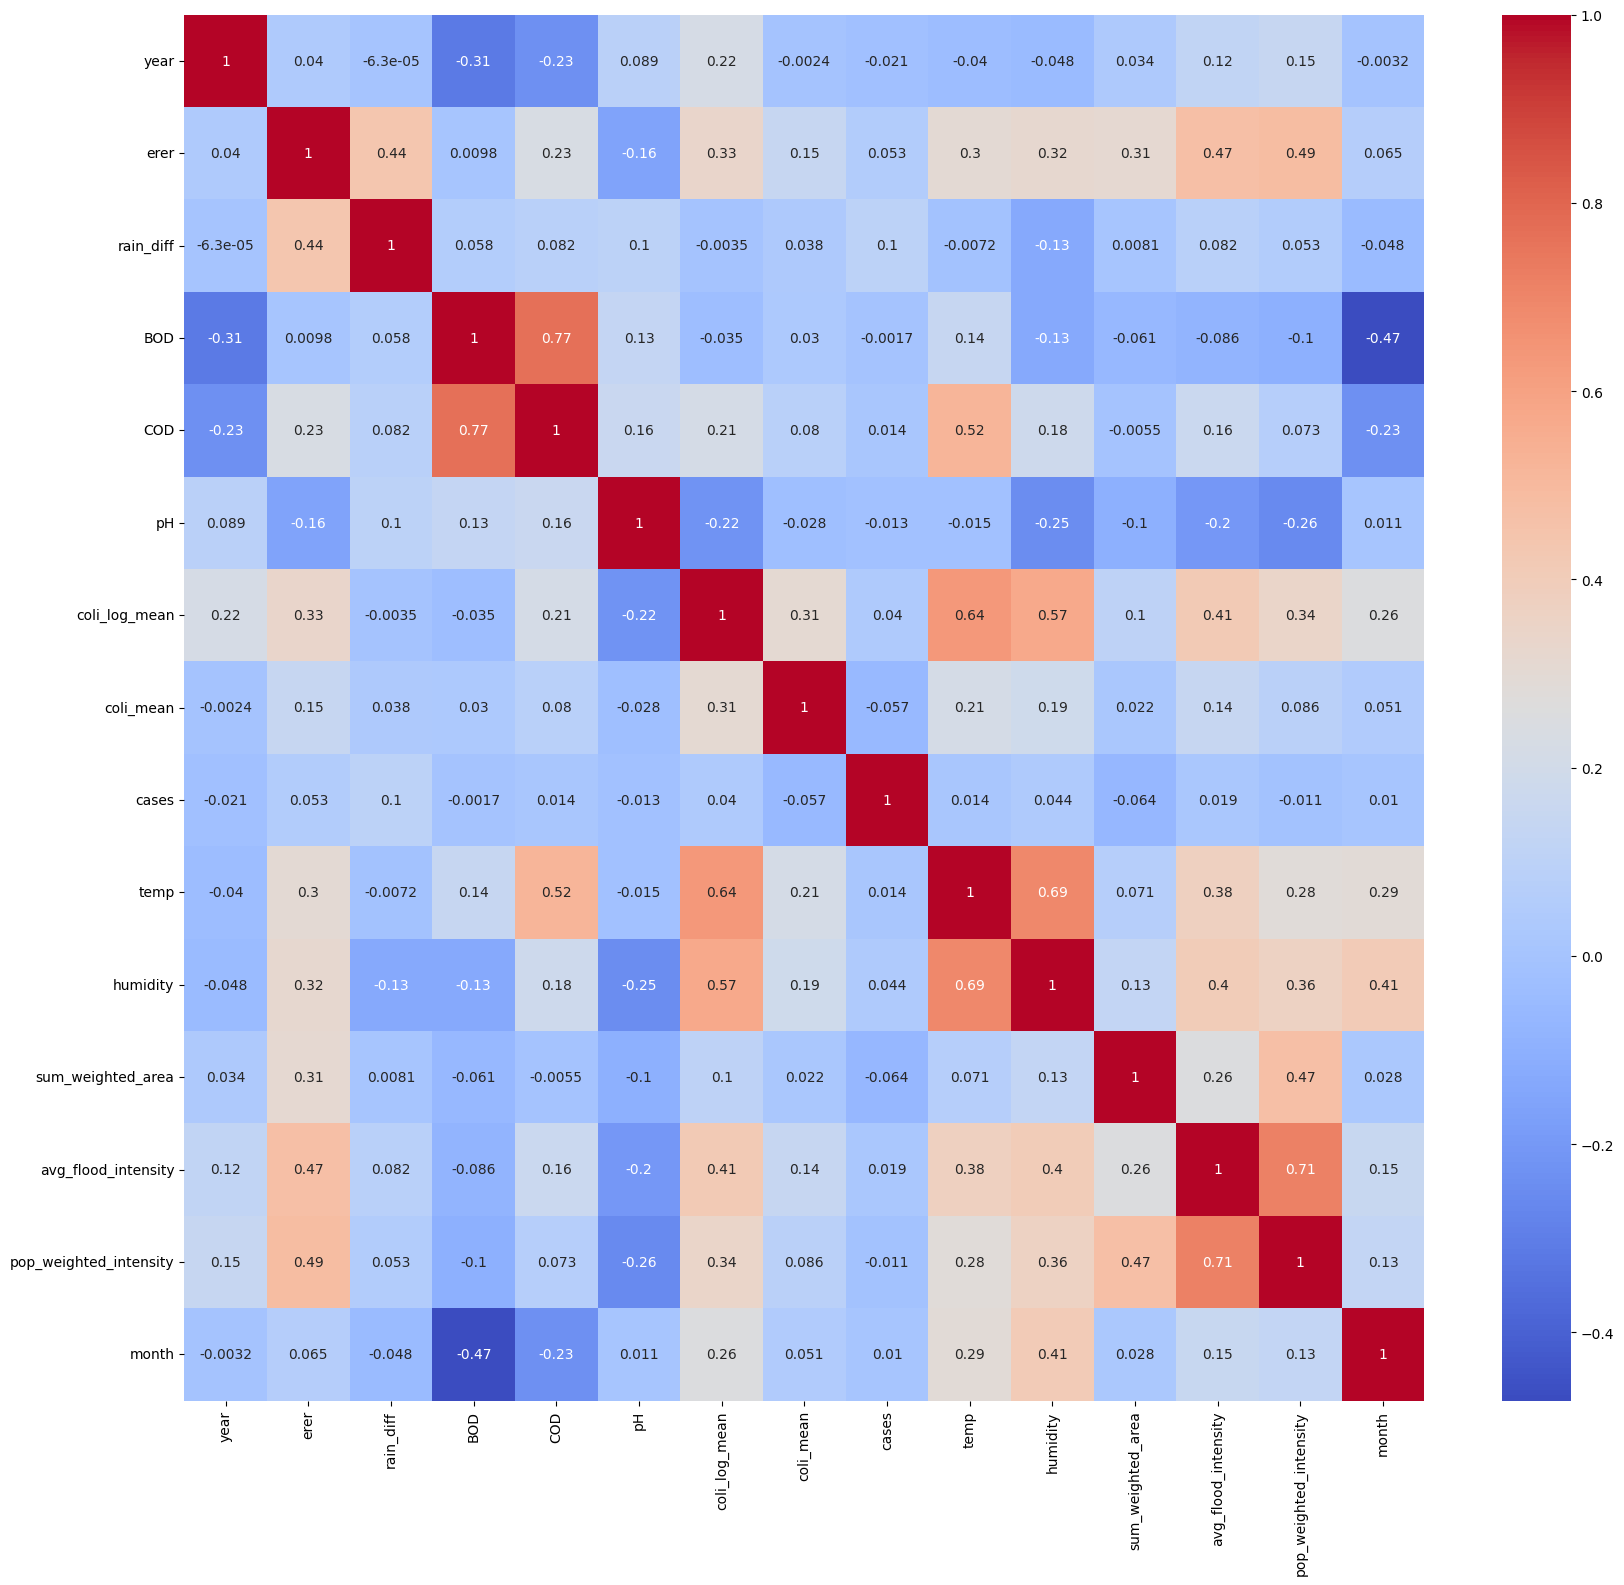

In [ ]:
corr=df2.drop(columns=['rain_nat', 'water_temp', 'DO', 'sum_flood_area', 'pop_area']).corr()
plt.figure(figsize=(20, 18))
sns.heatmap(corr, cmap='coolwarm', annot=True)
plt.show()

상관계수 0.7 이상 변수 제거

rain_nat, water_temp, DO, sum_flood_area, pop_area, temp, pop_weighted_intensity, COD 제거

In [ ]:
df3=df2.drop(columns=['rain_nat', 'water_temp', 'DO', 'sum_flood_area',
                      'pop_area', 'COD', 'pop_weighted_intensity'])

### 1.2.2 VIF 확인

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X=df3.drop(columns=['cases'])
X=X.dropna()
vif=pd.DataFrame()
vif['VIF Factor']=[variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['features']=X.columns
vif.sort_values('VIF Factor', ascending=False)

,VIF Factor,features
0,3640.243423,year
4,2961.546726,pH
5,178.477045,coli_log_mean
8,119.740742,humidity
3,17.728855,BOD
7,8.534853,temp
11,7.509328,month
1,2.197866,erer
10,1.727177,avg_flood_intensity
2,1.448546,rain_diff


In [ ]:
# pH 제거 후 VIF 확인
X=df3.drop(columns=['cases','pH'])
X=X.dropna()
vif=pd.DataFrame()
vif['VIF Factor']=[variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['features']=X.columns
vif.sort_values('VIF Factor', ascending=False)

,VIF Factor,features
0,232.187850,year
4,170.484847,coli_log_mean
7,113.302524,humidity
3,17.531634,BOD
6,8.003041,temp
10,7.308060,month
1,2.180761,erer
9,1.715949,avg_flood_intensity
2,1.431812,rain_diff
5,1.228981,coli_mean


In [ ]:
# humidity 제거 후 VIF 확인
X=df3.drop(columns=['cases', 'pH',
                   'humidity'])
X=X.dropna()
vif=pd.DataFrame()
vif['VIF Factor']=[variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['features']=X.columns
vif.sort_values('VIF Factor', ascending=False)

,VIF Factor,features
0,170.953135,year
4,167.902728,coli_log_mean
3,17.123356,BOD
9,7.071239,month
6,6.008795,temp
1,2.099721,erer
8,1.703960,avg_flood_intensity
2,1.337412,rain_diff
5,1.228685,coli_mean
7,1.164386,sum_weighted_area


In [ ]:
# coli_log_mean 제거 후 VIF 확인
X=df3.drop(columns=['cases', 'pH',
                   'humidity', 'coli_log_mean'])
X=X.dropna()
vif=pd.DataFrame()
vif['VIF Factor']=[variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['features']=X.columns
vif.sort_values('VIF Factor', ascending=False)

,VIF Factor,features
0,27.137541,year
3,16.955503,BOD
8,7.065013,month
5,4.457397,temp
1,2.069153,erer
7,1.662541,avg_flood_intensity
2,1.329684,rain_diff
4,1.170614,coli_mean
6,1.163962,sum_weighted_area


## 1.3 음이항 회귀

In [ ]:
df2=df.drop(columns=['year', 'week', 'week_start', 'cases_virus', 'cases_protozoa'])
df2=df2.rename(columns={'cases_bacteria':'cases'})

df2['month_sin']=np.sin(2*np.pi*df2['month']/12)
df2['month_cos']=np.cos(2*np.pi*df2['month']/12)

df4=df2[['temp', 'BOD', 'avg_flood_intensity', 'erer', 'sum_weighted_area', 'rain_diff', 'coli_mean', 'cases', 'month_cos', 'month_sin']]

In [ ]:
def make_lag(df, cols, lags):
    df=df.copy()

    for c in cols:
        for l in lags:
            df[f'{c}_lag{l}']=df[c].shift(l)
    return df

In [ ]:
cols=['erer', 'rain_diff']
#cols=['erer', 'rain_diff']
df4=make_lag(df4, cols, [0, 3])

cols=['sum_weighted_area', 'avg_flood_intensity']
#cols=['avg_flood_intensity', 'sum_weighted_area']
df4=make_lag(df4, cols, [0, 2])

cols=['temp']
#cols=['temp']
df4=make_lag(df4, cols, [0, 1])

In [ ]:
# 스케일링
from sklearn.preprocessing import StandardScaler

cols = [
    'temp_lag1',
    'avg_flood_intensity_lag2',
    'sum_weighted_area_lag2',
    'erer_lag3',
    'rain_diff_lag3'
]

scaler = StandardScaler()

df4[cols] = scaler.fit_transform(df4[cols])

In [ ]:
df5=df4.dropna()

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

formula = """
cases ~ temp_lag1
+ avg_flood_intensity_lag2
+ sum_weighted_area_lag2
+ erer_lag3 + rain_diff_lag3
+ month_sin + month_cos
"""

model=smf.glm(
    formula=formula,
    data=df5,
    family=sm.families.NegativeBinomial()
).fit()
model.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  cases   No. Observations:                  415
Model:                            GLM   Df Residuals:                      407
Model Family:        NegativeBinomial   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2445.1
Date:                Tue, 24 Feb 2026   Deviance:                       106.98
Time:                        05:12:36   Pearson chi2:                     81.6
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1593
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    4.8813      0.049     98.985      0.000       4.785       4.978
temp_lag1                   -0.0721      0.184     -0.392      0.695      -0.433       0.289
avg_flood_intensity_lag2     0.0542      0.057      0.949      0.343      -0.058       0.166
sum_weighted_area_lag2      -0.0026      0.051     -0.052      0.959      -0.103       0.098
erer_lag3                    0.0222      0.061      0.367      0.714      -0.097       0.141
rain_diff_lag3              -0.0026      0.056     -0.046      0.963      -0.112       0.107
month_sin                   -0.5283      0.193     -2.741      0.006      -0.906      -0.151
month_cos                   -0.3492      0.192     -1.823      0.068      -0.725       0.026
============================================================================================
"""

# 허들모델분석

In [ ]:
#우선 원충성질병에 대한 log처리는 하지 않음

1. 로지스틱-음이항분포 구조
근데 이 구조로 하는 게 말이 안되는게 lag를 다 넣어놓은 상태라서 좋은 결과가 나오기 어려움. 아래에 다중공선성 일으키는 변수 제거한 상태로 다시 적용함.

In [ ]:
df_h = df4.copy()

# inf 제거
df_h = df_h.replace([np.inf, -np.inf], np.nan)

# 필요한 변수만 선택
cols_for_model = df_h.columns.drop('year')

df_h = df_h[cols_for_model]

# 결측 제거
df_h = df_h.dropna().reset_index(drop=True)


In [ ]:
df_h['occurrence'] = (df_h['cases'] > 0).astype(int)

X_cols = df_h.columns.drop(['cases', 'occurrence'])

X1 = sm.add_constant(df_h[X_cols])
y1 = df_h['occurrence']



In [ ]:
#발생 건수에 대한 logistic회귀 모형 구동


from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, roc_auc_score

# X, y 정의
X = df_h[X_cols]
y_occ = df_h['occurrence']

tscv = TimeSeriesSplit(n_splits=5)

pipe_logit = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", LogisticRegression(max_iter=2000))
])

param_dist_logit = {
    "model__C": [0.01, 0.1, 1, 5, 10],
    "model__penalty": ["l2"],
}

search_logit = RandomizedSearchCV(
    pipe_logit,
    param_dist_logit,
    n_iter=5,
    cv=tscv,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1,
    refit=True
)

search_logit.fit(X, y_occ)

print("Best AUC:", search_logit.best_score_)
print("Best params:", search_logit.best_params_)


ValueError: 
All the 25 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
   

In [ ]:
#음이항

df_positive = df_h[df_h['cases'] > 0].copy()

X_pos = df_positive[X_cols]
y_pos = df_positive['cases']

X_pos = sm.add_constant(X_pos)

nb_model = sm.GLM(
    y_pos,
    X_pos,
    family=sm.families.NegativeBinomial()
)

nb_result = nb_model.fit()

print(nb_result.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:                  cases   No. Observations:                  304
Model:                            GLM   Df Residuals:                      275
Model Family:        NegativeBinomial   Df Model:                           28
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -566.60
Date:                Sat, 21 Feb 2026   Deviance:                       49.322
Time:                        18:32:08   Pearson chi2:                     63.3
No. Iterations:                     8   Pseudo R-squ. (CS):            0.02603
Covariance Type:            nonrobust                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

In [ ]:
# 발생 확률 (sklearn logistic)
prob = search_logit.predict_proba(X)[:, 1]

# 강도 예측 (NB)
mu = nb_result.predict(sm.add_constant(X))

# 최종 기대값
hurdle_pred = prob * mu


1.1) 다중공선성 일으키는 변수 통제 후 hurdle 구조 적용

In [ ]:
df5.columns

Index(['temp', 'BOD', 'avg_flood_intensity', 'erer', 'sum_weighted_area',
       'rain_diff', 'coli_mean', 'cases', 'month_cos', 'month_sin',
       'erer_lag0', 'erer_lag3', 'rain_diff_lag0', 'rain_diff_lag3',
       'sum_weighted_area_lag0', 'sum_weighted_area_lag2',
       'avg_flood_intensity_lag0', 'avg_flood_intensity_lag2', 'temp_lag0',
       'temp_lag1'],
      dtype='object')

In [ ]:
import pandas as pd
import numpy as np

# 1. 데이터 복사
df_h = df5.copy()

# 2. 분석에 사용할 변수 리스트 정의
selected_features = [
    'temp_lag1',
    'avg_flood_intensity_lag2',
    'sum_weighted_area_lag2',
    'erer_lag3',
    'rain_diff_lag3',
    'month_sin',
    'month_cos'
]

# 3. 타겟 변수(cases)와 선택된 변수들만 추출
# 만약 타겟 변수명이 다르면 'cases' 부분을 수정하세요.
df_h = df_h[selected_features + ['cases']]

# 4. 시차 변수로 인해 발생한 결측치 제거 (중요)
# 시차(Lag)를 적용하면 데이터의 초기 행들이 NaN이 됩니다.
# 통계 모델은 NaN이 있으면 작동하지 않으므로 제거해줍니다.
initial_shape = df_h.shape
df_h = df_h.dropna().reset_index(drop=True)

print(f"변수 선택 완료! 데이터 크기 변화: {initial_shape} -> {df_h.shape}")
print(df_h.head())

변수 선택 완료! 데이터 크기 변화: (415, 8) -> (415, 8)
   temp_lag1  avg_flood_intensity_lag2  sum_weighted_area_lag2  erer_lag3  \
0  -1.328173                 -0.366389               -0.061664  -0.356045   
1  -1.218895                 -0.366389               -0.061664  -0.356045   
2  -1.381561                 -0.366389               -0.061664  -0.356045   
3  -1.353568                 -0.366389               -0.061664  -0.356045   
4  -1.452933                 -0.366389               -0.061664  -0.356045   

   rain_diff_lag3  month_sin  month_cos  cases  
0        0.418057   0.500000   0.866025     22  
1       -0.287460   0.500000   0.866025     18  
2        0.166633   0.866025   0.500000     22  
3       -0.012111   0.866025   0.500000     29  
4       -0.230863   0.866025   0.500000     12  


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. 데이터 준비 (df_h 사용)
df_h = df5[['temp_lag1', 'avg_flood_intensity_lag2', 'sum_weighted_area_lag2',
            'erer_lag3', 'rain_diff_lag3', 'month_sin', 'month_cos', 'cases']].copy()

# 시차 변수로 인한 결측치 제거
df_h = df_h.dropna().reset_index(drop=True)

# 독립변수(X)와 종속변수(y) 설정
features = ['temp_lag1', 'avg_flood_intensity_lag2', 'sum_weighted_area_lag2',
            'erer_lag3', 'rain_diff_lag3', 'month_sin', 'month_cos']
X = sm.add_constant(df_h[features]) # 상수항(Intercept) 추가
y = df_h['cases']

# ---------------------------------------------------------
# [Step 1] Logistic Regression (발생 여부: 0 vs >0)
# ---------------------------------------------------------
y_binary = (y > 0).astype(int)
logit_model = sm.Logit(y_binary, X).fit(disp=0)
prob_occurrence = logit_model.predict(X)

print("=== [Step 1] Logistic Regression Summary ===")
print(logit_model.summary().tables[1]) # 계수 표만 출력

# ---------------------------------------------------------
# [Step 2] Negative Binomial Regression (발생 시 규모 예측)
# ---------------------------------------------------------
# 발생한 케이스(y > 0)에 대해서만 학습
df_positive = df_h[y > 0]
X_positive = sm.add_constant(df_positive[features])
y_positive = df_positive['cases']

# 음이항 회귀 (과분산 문제를 해결하기 위해 Poisson 대신 사용)
nb_model = sm.GLM(y_positive, X_positive, family=sm.families.NegativeBinomial()).fit()
pred_counts = nb_model.predict(X)

print("\n=== [Step 2] Negative Binomial Summary ===")
print(nb_model.summary().tables[1])

# ---------------------------------------------------------
# [Step 3] 최종 결합 및 성능 평가
# ---------------------------------------------------------
# 최종 예측값 = P(발생) * E(발생 시 건수)
final_pred = prob_occurrence * pred_counts

# 성능 지표 계산
mae = mean_absolute_error(y, final_pred)
rmse = np.sqrt(mean_squared_error(y, final_pred))
r2 = r2_score(y, final_pred)

print(f"\n" + "="*40)
print(f"Final Hurdle Model Performance")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R2   : {r2:.4f}")
print("="*40)

#R-square 뒤에 있는 light gbm 모델이 좀 더 성능 좋은 것으로 평가됨.

=== [Step 1] Logistic Regression Summary ===
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       33.1657   4.78e+04      0.001      0.999   -9.36e+04    9.37e+04
temp_lag1                   -0.0630   3.57e+04  -1.77e-06      1.000   -6.99e+04    6.99e+04
avg_flood_intensity_lag2    -3.5443   1.39e+04     -0.000      1.000   -2.72e+04    2.72e+04
sum_weighted_area_lag2      -0.1253   1381.499  -9.07e-05      1.000   -2707.814    2707.563
erer_lag3                   -3.3905   1.04e+04     -0.000      1.000   -2.04e+04    2.04e+04
rain_diff_lag3               3.4456   1.36e+04      0.000      1.000   -2.66e+04    2.66e+04
month_sin                   -7.2374   4.06e+04     -0.000      1.000   -7.95e+04    7.95e+04
month_cos                   -7.0424   4.36e+04     -0.000      1.000   -8.54e+04    8.54e+04

=== [Step 2] Negative Bi

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packa

2. lgbm 기반 hurdle

In [ ]:
import numpy as np
import pandas as pd

# ---------------------------
# 1. 타겟 변수 생성
# ---------------------------
df_h = df4.copy()

df_h["occurrence"] = (df_h["cases"] > 0).astype(int)

# feature 목록 (year, cases 제외)
feature_cols = [col for col in df_h.columns if col not in ["cases", "occurrence"]]

X = df_h[feature_cols]
y_class = df_h["occurrence"]
y_reg = df_h["cases"]


In [ ]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
    accuracy_score
)
import lightgbm as lgb


In [ ]:
#1단계 발생 여부로 모델링.

# -------------------------
# RMSE scorer (회귀용에서 사용)
# -------------------------
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

tscv = TimeSeriesSplit(n_splits=5)

# -------------------------
# Pipeline
# -------------------------
pipe_clf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", lgb.LGBMClassifier(random_state=42, verbosity=-1))
])

param_dist_clf = {
    "model__n_estimators": [300, 500, 800],
    "model__learning_rate": [0.01, 0.03, 0.05],
    "model__max_depth": [-1, 3, 4, 5],
    "model__num_leaves": [15, 31, 63],
    "model__min_child_samples": [10, 20, 30],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

search_clf = RandomizedSearchCV(
    estimator=pipe_clf,
    param_distributions=param_dist_clf,
    n_iter=30,
    scoring="roc_auc",
    cv=tscv,
    n_jobs=-1,
    random_state=42,
    refit=True
)

search_clf.fit(X, y_class)

print("Best ROC-AUC:", search_clf.best_score_)
print("Best Params:", search_clf.best_params_)

best_clf = search_clf.best_estimator_


Best ROC-AUC: nan
Best Params: {'model__subsample': 0.7, 'model__num_leaves': 63, 'model__n_estimators': 800, 'model__min_child_samples': 30, 'model__max_depth': 5, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.7}


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


In [ ]:
#2단계 발생 강도로 모델링

df_pos = df_h[df_h["cases"] > 0]

X_reg = df_pos[feature_cols]
y_reg_pos = df_pos["cases"]

pipe_reg = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", lgb.LGBMRegressor(
        random_state=42,
        verbosity=-1,
        objective="poisson"  # count 데이터 반영
    ))
])

param_dist_reg = {
    "model__n_estimators": [300, 500, 800],
    "model__learning_rate": [0.01, 0.03, 0.05],
    "model__max_depth": [-1, 3, 4, 5],
    "model__num_leaves": [15, 31, 63],
    "model__min_child_samples": [10, 20, 30],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

search_reg = RandomizedSearchCV(
    estimator=pipe_reg,
    param_distributions=param_dist_reg,
    n_iter=30,
    scoring=make_scorer(rmse, greater_is_better=False),
    cv=tscv,
    n_jobs=-1,
    random_state=42,
    refit=True
)

search_reg.fit(X_reg, y_reg_pos)

print("Best RMSE:", -search_reg.best_score_)
print("Best Params:", search_reg.best_params_)

best_reg = search_reg.best_estimator_


Best RMSE: 82.84064410176725
Best Params: {'model__subsample': 0.9, 'model__num_leaves': 63, 'model__n_estimators': 800, 'model__min_child_samples': 10, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.9}


In [ ]:
#두개의 확률을 합쳐서 최종 모델링

# 발생 확률
prob = best_clf.predict_proba(X)[:, 1]

# 강도 예측
intensity = best_reg.predict(X)

# 최종 기대값
final_pred = prob * intensity


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
# 실제값
y_true = df_h["cases"]

rmse_total = np.sqrt(mean_squared_error(y_true, final_pred))
mae_total = mean_absolute_error(y_true, final_pred)
r2_total = r2_score(y_true, final_pred)

print("===== Final Hurdle Model Performance =====")
print("RMSE:", rmse_total)
print("MAE :", mae_total)
print("R2  :", r2_total)

#MAE: 모델이 예측한 값과 실제 값 사이의 평균적 절대적 거리
#질병 건수를 예측할 때 평균적으로 약 0.6건 정도의 오차.

#RMSE가 더 크다는 것은 모델이 특정 이상치 예측에 실패했다는 뜻

===== Final Hurdle Model Performance =====
RMSE: 170.57738285209385
MAE : 143.81578947368408
R2  : -2.458261422324345


In [ ]:
df4[df4['cases'] > 0]['cases'].mean()

np.float64(143.81578947368422)

2.2) Robust scaler 적용 후 tree 모델 적용

로그 변환 적용하지 않고, outlier/0값이 많지만 변수 자체의 특성이 중요하다는 것을 고려하여 robustsclaer 적용, 모델 성능 개선.

In [ ]:
import numpy as np

In [ ]:
df_r=df4.copy()

In [ ]:
df_r.head()

,temp,BOD,avg_flood_intensity,erer,sum_weighted_area,rain_diff,coli_mean,cases,month_cos,month_sin,erer_lag0,erer_lag3,rain_diff_lag0,rain_diff_lag3,sum_weighted_area_lag0,sum_weighted_area_lag2,avg_flood_intensity_lag0,avg_flood_intensity_lag2,temp_lag0,temp_lag1
0,-0.262836,1.936856,0.0,0.0,0.0,3.772672,3550.337910,6,0.866025,0.5,0.0,NaN,3.772672,NaN,0.0,NaN,0.0,NaN,-0.262836,NaN
1,-0.013854,2.436846,0.0,0.0,0.0,-2.587254,12603.782446,12,0.866025,0.5,0.0,NaN,-2.587254,NaN,0.0,NaN,0.0,NaN,-0.013854,-1.845406
2,0.037085,2.379334,0.0,0.0,0.0,1.506199,21492.608976,13,0.866025,0.5,0.0,NaN,1.506199,NaN,0.0,-0.061664,0.0,-0.366389,0.037085,-1.416021
3,0.100451,1.649368,0.0,0.0,0.0,-0.105095,4912.063715,22,0.866025,0.5,0.0,-0.356045,-0.105095,0.418057,0.0,-0.061664,0.0,-0.366389,0.100451,-1.328173
4,0.006128,3.622871,0.0,0.0,0.0,-2.077051,13864.366463,18,0.866025,0.5,0.0,-0.356045,-2.077051,-0.287460,0.0,-0.061664,0.0,-0.366389,0.006128,-1.218895


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. 데이터 준비 및 Scaling
df_r = df4.copy()
scaler = RobustScaler()

# 타겟 변수(cases)에 RobustScaler 적용 (2차원 배열 형태 필요)
# 주의: 회귀 단계의 해석을 위해 원본을 백업해두거나 scaler 객체를 잘 보존하세요.
df_r['cases_scaled'] = scaler.fit_transform(df_r[['cases']])

# 2. Hurdle 모델용 데이터 분리
# 1단계: 발생 여부 (Binary)
df_r['occurrence'] = (df_r['cases'] > 0).astype(int)

# 2단계: 발생한 경우만 (Positive)
df_positive = df_r[df_r['occurrence'] == 1].copy()

# 3. 모델 정의 및 학습 (LightGBM)
# 분석 환경에 맞춰 Feature(X) 컬럼 리스트를 지정하세요.
features = [col for col in df_r.columns if col not in ['cases', 'cases_scaled', 'occurrence']]
X = df_r[features]

# [Step 1] Classifier: 발생 여부 예측
clf = LGBMClassifier(random_state=42)
clf.fit(X, df_r['occurrence'])
prob_occurrence = clf.predict_proba(X)[:, 1] # 발생 확률

# [Step 2] Regressor: 발생 규모 예측 (Positive 데이터만 사용)
reg = LGBMRegressor(random_state=42)
reg.fit(df_positive[features], df_positive['cases_scaled'])
pred_positive_scaled = reg.predict(X)

# 4. 최종 결합 예측 (Expected Value)
# E(Y) = P(Y>0) * E(Y|Y>0)
final_pred_scaled = prob_occurrence * pred_positive_scaled

# 5. 역변환(Inverse Transform) 및 평가
# 해석을 위해 스케일링된 예측값을 다시 원본 단위(건수)로 돌립니다.
final_pred_orig = scaler.inverse_transform(final_pred_scaled.reshape(-1, 1)).flatten()
y_true = df_r['cases'].values

print(f"Inverse-Transformed MAE: {mean_absolute_error(y_true, final_pred_orig)}")
print(f"Inverse-Transformed RMSE: {np.sqrt(mean_squared_error(y_true, final_pred_orig))}")
print(f"R2 Score: {r2_score(y_true, final_pred_orig)}")


#R square 0.67 정도로 개선됨.

Inverse-Transformed MAE: 70.37559808612434
Inverse-Transformed RMSE: 94.76736815479066
R2 Score: -0.06741319203947427
